# Gold Standard Evaluation
Comparison between model classifications (`classified_all_tweets_final_v2_clean.csv`) and human annotations from **Annotator A** and **Annotator B** (`gold_standard_annotator_A.xlsx`, `gold_standard_annotator_B.xlsx`).

Two dimensions are evaluated: **Topic** and **Stance**.

**Sections:**
1. Imports & Setup
2. Load data
3. Merge
4. Global agreement metrics (Accuracy + Cohen's Kappa)
5. Confusion matrices
6. Per-class metrics (Precision / Recall / F1)
7. Disagreement analysis
8. Inter-annotator agreement (A vs B)
9. Export results

## 1. Imports & Setup

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score,
    confusion_matrix, classification_report, f1_score
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

TOPIC_LABELS = [
    'Economy and Employment',
    'Immigration and Security',
    'International Affairs',
    'National Politics and Governance',
    'Other',
    'Rights and Equality',
    'Welfare, Housing and Social Policy'
]
STANCE_LABELS = ['Against', 'In favor', 'Neutral', 'Unclear']

ANNOTATORS = ['A', 'B']

## 2. Load Data
This section loads the datasets required for the evaluation of the LLM classifications. The first dataset corresponds to the complete collection of tweets classified automatically by the model, while the second dataset contains the manually annotated gold standard generated by two human annotators.

To facilitate the comparison between datasets, a normalized version of the tweet text is created by removing extra spaces and converting all characters to lowercase. This preprocessing step helps ensure consistent matching of tweets across files.

In [142]:
model = pd.read_csv('classified_all_tweets_final_v2_clean.csv')
model['tweet_norm'] = model['tweet'].str.strip().str.lower()

gold = {}
for ann in ANNOTATORS:
    df_ann = pd.read_excel(f'gold_standard_annotator_{ann}.xlsx') 
    df_ann['tweet_norm'] = df_ann['tweet'].str.strip().str.lower()
    gold[ann] = df_ann
    print(f'Annotator {ann}: {len(df_ann)} tweets')

print(f'Model:          {len(model)} tweets')
print()
print('Gold columns:', gold['A'].columns.tolist())
print('Model columns:', model.columns.tolist())

Annotator A: 200 tweets
Annotator B: 200 tweets
Model:          11866 tweets

Gold columns: ['sample_order', 'tweet_id', 'date', 'politician', 'tweet', 'annotator_topic', 'annotator_stance', 'annotator_notes', 'tweet_norm']
Model columns: ['row_id', 'tweet_id', 'tweet', 'topic', 'stance', 'short_justification', 'date', 'politician', 'year', 'month', 'quarter', 'tweet_norm']


The output confirms that both annotators labeled the same number of tweets, with 200 annotated instances each. In contrast, the LLM-generated dataset contains 11866 classified tweets, representing the full corpus used throughout the study.

The inspection of the dataset columns also shows that the gold standard includes the manual annotations for both topic and stance, together with optional annotation notes. Meanwhile, the model dataset contains the corresponding automatic predictions generated by the LLM, as well as additional temporal variables such as year, month, and quarter.

## 3. Merge
This section merges the manually annotated gold standard with the classifications generated by the LLM. The objective is to create, for each annotator, a single evaluation dataset containing both the human labels and the model predictions for the same tweets.

> **Note:** Twitter IDs are 64-bit integers (~10¹⁸). Excel only represents integers exactly up to 2⁵³, so the last digits of tweet IDs get corrupted when saved as `.xlsx`. The merge is done on the **tweet text** instead, which is reliable.

In [143]:
# Merge each annotator's gold standard with model classifications
merged = {}
for ann in ANNOTATORS:
    df = gold[ann].merge(
        model[['tweet_norm', 'tweet_id', 'topic', 'stance']],
        on='tweet_norm',
        how='inner',
        suffixes=('_gold', '_model')
    ).rename(columns={
        'annotator_topic':  'gold_topic',
        'annotator_stance': 'gold_stance',
        'topic':  'model_topic',
        'stance': 'model_stance',
        'tweet_id_model': 'tweet_id'
    })
    merged[ann] = df
    n = len(gold[ann])
    m = len(df)
    print(f'Annotator {ann}: {m}/{n} tweets matched ({m/n*100:.1f}%)')

# Tweets annotated by BOTH annotators (for IAA)
common_tweets = set(gold['A']['tweet_norm']) & set(gold['B']['tweet_norm'])
print(f'\nTweets in common (A ∩ B): {len(common_tweets)}')

Annotator A: 200/200 tweets matched (100.0%)
Annotator B: 200/200 tweets matched (100.0%)

Tweets in common (A ∩ B): 200


## 4. Global Agreement Metrics
This section calculates the main agreement metrics used to evaluate the performance of the LLM against the human gold standard. The comparison is carried out separately for topic classification and stance classification, since both tasks measure different aspects of the tweets.

Accuracy is used to measure the percentage of exact matches between the model and the annotator. Cohen’s Kappa is also calculated because it corrects the agreement by considering the agreement that could occur by chance. In addition, a 95% confidence interval is estimated through bootstrapping, which provides a more robust view of the stability of the Kappa value.

In [144]:
def kappa_label(k):
    if   k < 0.00: return 'no agreement'
    elif k < 0.20: return 'slight'
    elif k < 0.40: return 'fair'
    elif k < 0.60: return 'moderate'
    elif k < 0.80: return 'substantial'
    else:          return 'almost perfect'

def bootstrap_kappa(y_true, y_pred, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    n = len(y_true)
    boots = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        boots.append(cohen_kappa_score(y_true[idx], y_pred[idx]))
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return lo, hi

def print_agreement(y_true, y_pred, label, labels=None):
    acc   = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    lo, hi = bootstrap_kappa(y_true, y_pred)
    n     = len(y_true)
    n_ok  = (y_true == y_pred).sum()
    print(f'  [{label}]')
    print(f'    Tweets evaluated : {n}')
    print(f'    Agreements       : {n_ok} ({acc*100:.1f}%)')
    print(f'    Disagreements    : {n - n_ok} ({(1-acc)*100:.1f}%)')
    print(f'    Accuracy         : {acc:.4f}')
    print(f"    Cohen's Kappa    : {kappa:.4f}  ({kappa_label(kappa)})")
    print(f'    95% CI for Kappa : [{lo:.4f}, {hi:.4f}]')
    return acc, kappa, (lo, hi)



results = {}  # store (acc_topic, kappa_topic, acc_stance, kappa_stance) per annotator

for ann in ANNOTATORS:
    df = merged[ann]
    print(f'── Annotator {ann} ──')
    at, kt, ci_t = print_agreement(df['gold_topic'],  df['model_topic'],  'TOPIC',  labels=TOPIC_LABELS)
    print()
    as_, ks, ci_s = print_agreement(df['gold_stance'], df['model_stance'], 'STANCE', labels=STANCE_LABELS)
    f1_t = f1_score(df['gold_topic'],  df['model_topic'],  labels=TOPIC_LABELS,  average='macro', zero_division=0)
    f1_s = f1_score(df['gold_stance'], df['model_stance'], labels=STANCE_LABELS, average='macro', zero_division=0)
    print(f'    Macro-F1 topic : {f1_t:.4f}')
    print(f'    Macro-F1 stance: {f1_s:.4f}')
    results[ann] = dict(
        acc_topic=at, kappa_topic=kt, ci_topic=ci_t, f1_macro_topic=f1_t,
        acc_stance=as_, kappa_stance=ks, ci_stance=ci_s, f1_macro_stance=f1_s,
    )
    print()

── Annotator A ──
  [TOPIC]
    Tweets evaluated : 200
    Agreements       : 150 (75.0%)
    Disagreements    : 50 (25.0%)
    Accuracy         : 0.7500
    Cohen's Kappa    : 0.6844  (substantial)
    95% CI for Kappa : [0.6044, 0.7574]

  [STANCE]
    Tweets evaluated : 200
    Agreements       : 160 (80.0%)
    Disagreements    : 40 (20.0%)
    Accuracy         : 0.8000
    Cohen's Kappa    : 0.6474  (substantial)
    95% CI for Kappa : [0.5512, 0.7340]
    Macro-F1 topic : 0.7112
    Macro-F1 stance: 0.6301

── Annotator B ──
  [TOPIC]
    Tweets evaluated : 200
    Agreements       : 142 (71.0%)
    Disagreements    : 58 (29.0%)
    Accuracy         : 0.7100
    Cohen's Kappa    : 0.6392  (substantial)
    95% CI for Kappa : [0.5607, 0.7191]

  [STANCE]
    Tweets evaluated : 200
    Agreements       : 153 (76.5%)
    Disagreements    : 47 (23.5%)
    Accuracy         : 0.7650
    Cohen's Kappa    : 0.5834  (moderate)
    95% CI for Kappa : [0.4883, 0.6733]
    Macro-F1 topic : 0

Agreement with the human gold standard falls in the *substantial* band of the
Landis–Koch scale for three of the four configurations. Topic classification
achieves κ = 0.684 against Annotator A (95% CI [0.604, 0.757]) and κ = 0.639
against Annotator B (95% CI [0.561, 0.719]). Stance reaches κ = 0.647 against
A (95% CI [0.551, 0.734]) and drops to κ = 0.583 against B (95% CI [0.488,
0.673]); the lower bound of the latter crosses into the *moderate* band, which
is the only configuration where the model's agreement is not unambiguously
substantial.

The bootstrap confidence intervals of A and B overlap in every comparison.
This means the difference between annotators is not statistically distinguishable
at the 95% level. The model is therefore stable across annotators rather than
calibrated to a single reference, which is a desirable property for a classifier
intended to operate at corpus scale.

The contrast between accuracy and macro-F1 is informative. For topic the two
metrics stay close (A: 0.750 vs 0.711; B: 0.710 vs 0.662), suggesting that
per-class performance is reasonably balanced across the seven categories. For
stance, however, the gap widens to roughly 17 and 21 percentage points (A:
0.800 vs 0.630; B: 0.765 vs 0.557). Macro-F1 weighs each class equally, so
this gap indicates that headline accuracy is sustained by the majority labels
(`In favor`, `Against`) while the minority labels (`Neutral`, `Unclear`)
are predicted poorly. Section 6 inspects the per-class breakdown that
produces this asymmetry.

In summary, the model performs at substantial agreement on topic classification
and at the boundary between substantial and moderate on stance, with the
weakness localized in the minority stance classes rather than spread evenly
across the label space.

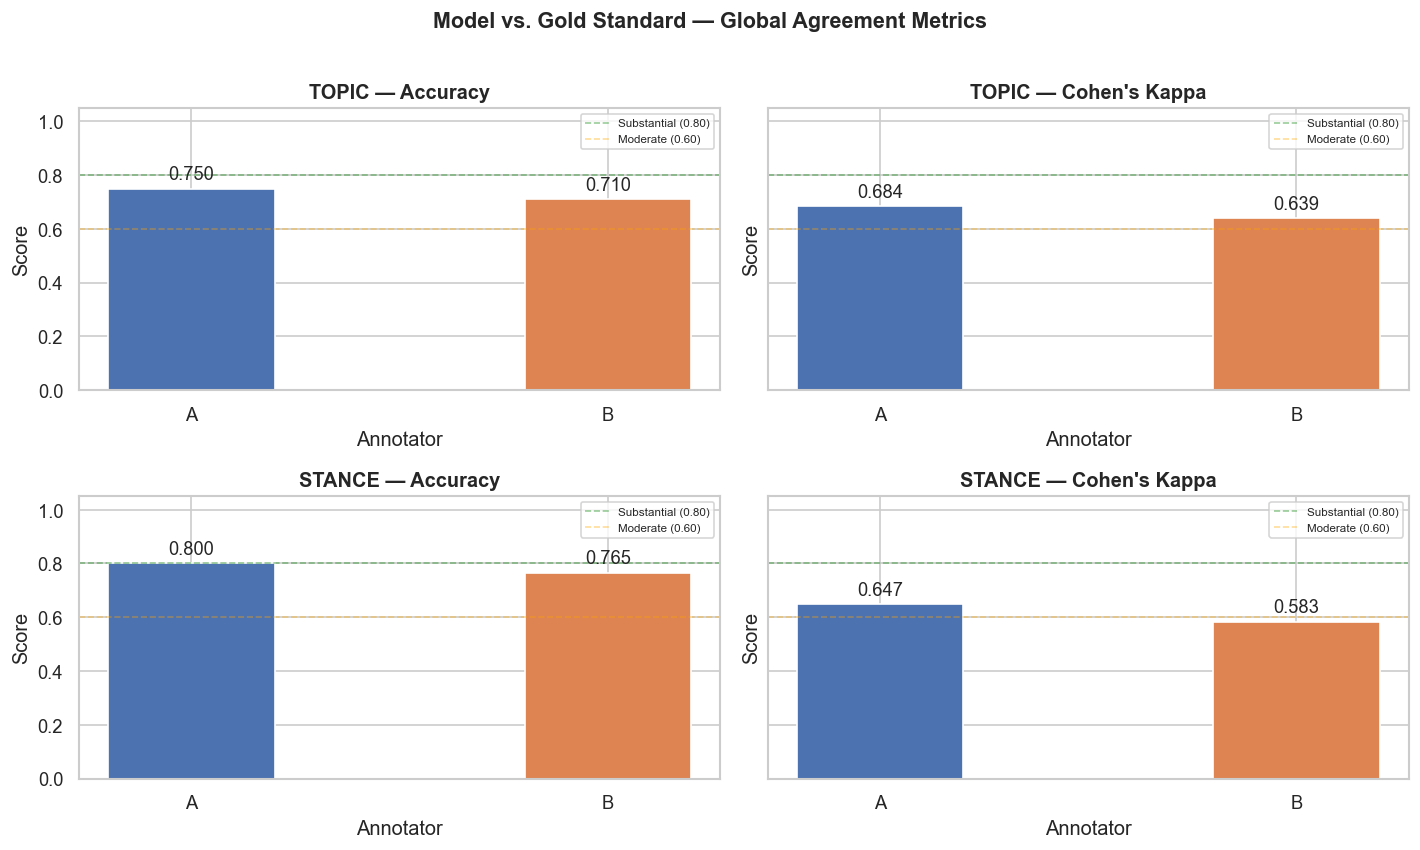

In [145]:
# Visual summary: side-by-side bar charts per annotator
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)

colors = ['#4C72B0', '#DD8452']
metrics_map = [
    ('TOPIC — Accuracy',       'acc_topic'),
    ('TOPIC — Cohen\'s Kappa', 'kappa_topic'),
    ('STANCE — Accuracy',      'acc_stance'),
    ('STANCE — Cohen\'s Kappa','kappa_stance'),
]

for ax, (title, key) in zip(axes.flat, metrics_map):
    vals = [results[ann][key] for ann in ANNOTATORS]
    bars = ax.bar(ANNOTATORS, vals, color=colors, width=0.4, edgecolor='white')
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Annotator')
    ax.set_ylabel('Score')
    ax.axhline(0.80, color='green',  linestyle='--', alpha=0.4, linewidth=1, label='Substantial (0.80)')
    ax.axhline(0.60, color='orange', linestyle='--', alpha=0.4, linewidth=1, label='Moderate (0.60)')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=11)
    ax.legend(fontsize=7)

plt.suptitle('Model vs. Gold Standard — Global Agreement Metrics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The figure summarizes the four global metrics with the Landis–Koch thresholds
overlaid as dashed reference lines: orange for the *moderate* boundary (κ =
0.60) and green for the *substantial* boundary (κ = 0.80). Visualizing the
metrics in this way makes the position of each value relative to the
interpretive bands immediately readable.

Three patterns are visible at a glance. First, all four accuracy values sit
near or just below the 0.80 reference line, with stance accuracy against
Annotator A reaching the line exactly. Accuracy alone would suggest that the
model is close to substantial agreement on both tasks.

Second, the Cohen's κ values sit consistently lower than their accuracy
counterparts, as expected: κ corrects for the agreement attributable to chance,
and the gap reflects the prior imbalance of the label distribution. All κ values remain above the 0.60 moderate threshold except stance
against Annotator B (κ = 0.583), which falls slightly below the line and is
the only metric reported in the *moderate* band.

Third, the model performs marginally better against Annotator A than against
Annotator B across all four metrics. The gap is small (between 0.04 and 0.06
points) and, as shown by the overlapping bootstrap intervals in the preceding
section, not statistically significant. It reflects differences in how each
annotator applied the coding guide rather than a calibration bias in the
classifier.


## 5. Confusion Matrices
This section visualizes the agreement between the human annotations and the LLM predictions using confusion matrices. 

Each row represents the human annotation, while each column represents the model prediction. The values are shown both as absolute counts and as percentages within each gold-standard row, making it easier to identify which categories are correctly classified and where the model tends to make mistakes.

In [146]:
def plot_confusion(y_true, y_pred, labels, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([
        [f'{v}\n({p:.0f}%)' for v, p in zip(rv, rp)]
        for rv, rp in zip(cm, cm_pct)
    ])
    sns.heatmap(
        cm_pct, annot=annot, fmt='', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, linecolor='white',
        cbar_kws={'label': '% per gold row'}, ax=ax
    )
    ax.set_xlabel('Model prediction', fontsize=10)
    ax.set_ylabel('Human annotation (gold)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

Exception ignored in: <function ZipFile.__del__ at 0x000002B1C3F59260>
Traceback (most recent call last):
  File "C:\Users\narci\AppData\Local\Programs\Python\Python313\Lib\zipfile\__init__.py", line 1975, in __del__
    self.close()
  File "C:\Users\narci\AppData\Local\Programs\Python\Python313\Lib\zipfile\__init__.py", line 1992, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file
Exception ignored in: <function ZipFile.__del__ at 0x000002B1C3F59260>
Traceback (most recent call last):
  File "C:\Users\narci\AppData\Local\Programs\Python\Python313\Lib\zipfile\__init__.py", line 1975, in __del__
    self.close()
  File "C:\Users\narci\AppData\Local\Programs\Python\Python313\Lib\zipfile\__init__.py", line 1992, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


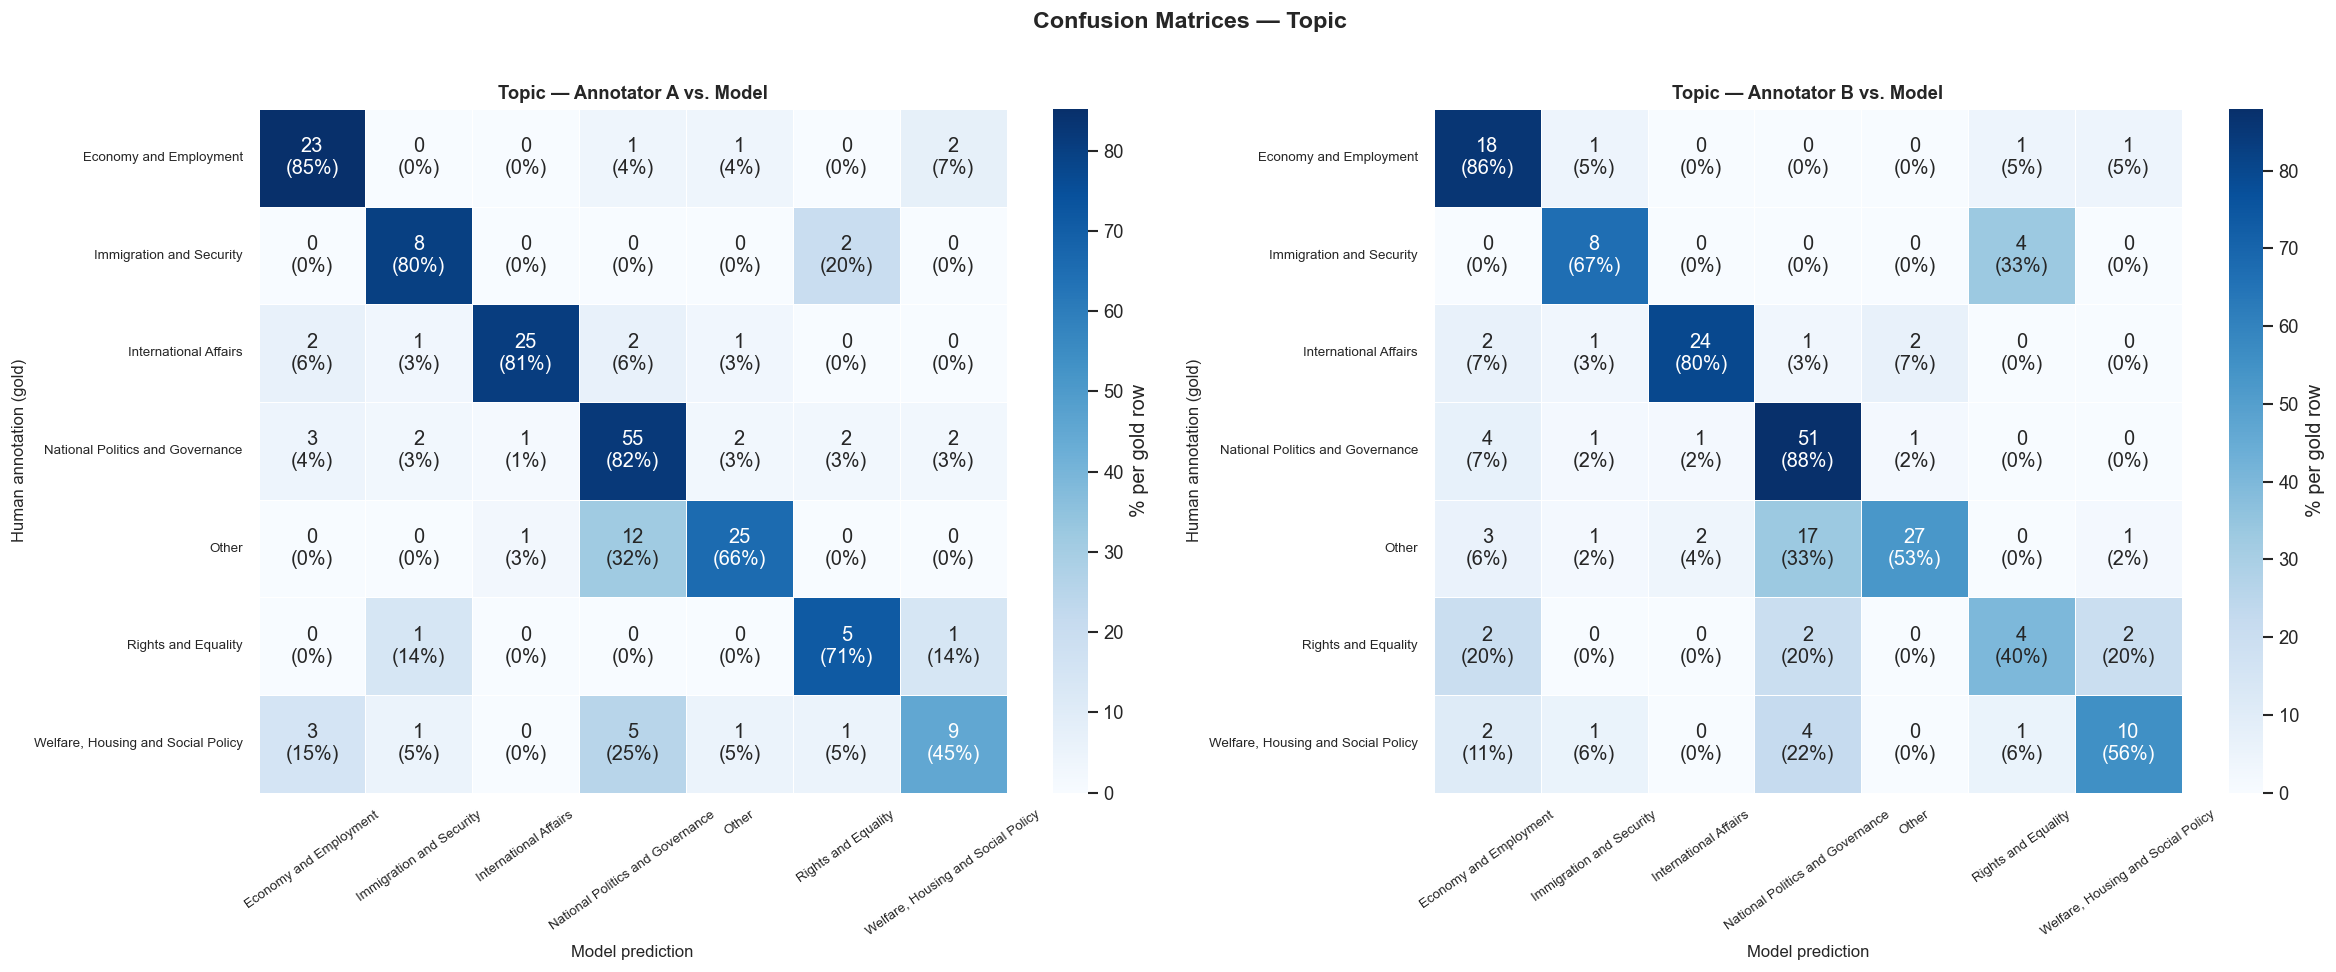

In [147]:
# Topic confusion matrices — one per annotator
fig, axes = plt.subplots(1, len(ANNOTATORS), figsize=(10 * len(ANNOTATORS), 8))
if len(ANNOTATORS) == 1:
    axes = [axes]
for ax, ann in zip(axes, ANNOTATORS):
    df = merged[ann]
    plot_confusion(df['gold_topic'], df['model_topic'], TOPIC_LABELS,
                   f'Topic — Annotator {ann} vs. Model', ax)
plt.suptitle('Confusion Matrices — Topic', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The confusion matrices show that several topic categories achieve consistently high recall across both annotators. In particular, `Economy and Employment`, `International Affairs`, and `National Politics and Governance` concentrate most of the correct classifications located on the diagonal of the matrices. `Economy and Employment` reaches recall values of 85% against Annotator A and 86% against Annotator B, while `International Affairs` achieves 81% and 80%, respectively. Similarly, `National Politics and Governance` obtains recall values of 82% and 88%. These categories are both highly represented in the dataset and relatively well defined in the coding scheme, which explains their strong contribution to the overall agreement metrics presented previously.

The most important source of disagreement appears in the `Other` category. In both matrices, a substantial proportion of tweets manually labelled as `Other` are instead classified by the model as `National Politics and Governance`. For Annotator A, 12 out of 38 tweets in `Other` are reassigned to governance-related content, while for Annotator B the same pattern appears in 17 out of 51 tweets. This suggests that the model tends to avoid the residual `Other` category and prefers assigning tweets to broader political topics whenever some political context is present.

This disagreement can also be partially explained by an information asymmetry between the human annotators and the classifier. The coding guide instructed annotators to classify tweets using only the tweet text itself, without considering metadata such as the politician identity or the publication date. The classifier, in contrast, had access to these metadata fields and additionally relied on broader political knowledge acquired during pretraining, allowing it to infer implicit references, political actors, or context-dependent language.

As a consequence, some tweets that appeared too ambiguous or context-limited for the annotators were labelled as `Other`, while the classifier assigned them to `National Politics and Governance` based on inferred political context. For example, a tweet announcing a television appearance may reasonably be interpreted as non-thematic by a text-only annotator, while the classifier may associate it with political communication activity. Therefore, part of the `Other → National Politics and Governance` disagreement should be interpreted as a boundary effect of the evaluation protocol rather than as a clear classification failure. In this sense, the gold standard functions as a methodological reference point rather than as absolute ground truth.

`Welfare, Housing and Social Policy` presents the lowest recall values among the main categories, with 45% agreement against Annotator A and 56% against Annotator B. Most of these tweets are reassigned either to `National Politics and Governance` or to `Economy and Employment`. This behaviour reflects the conceptual overlap between these topics, as discussions about pensions, housing, or welfare policies are frequently framed in both economic and governmental terms. In these ambiguous situations, the model tends to favour the broader and more general political categories.

Another visible source of confusion occurs between `Immigration and Security` and `Rights and Equality`. In a small number of cases, tweets labelled as immigration-related by the annotators are classified by the model under rights-related themes instead. Although the number of affected tweets is relatively low, this confusion has a noticeable impact on the recall of the immigration category, particularly for Annotator B.

Finally, the category `Rights and Equality` contains very few examples in both annotated samples. As a consequence, its recall values fluctuate considerably between annotators and should be interpreted cautiously. Because the category is underrepresented, small classification changes can strongly affect the resulting percentages.

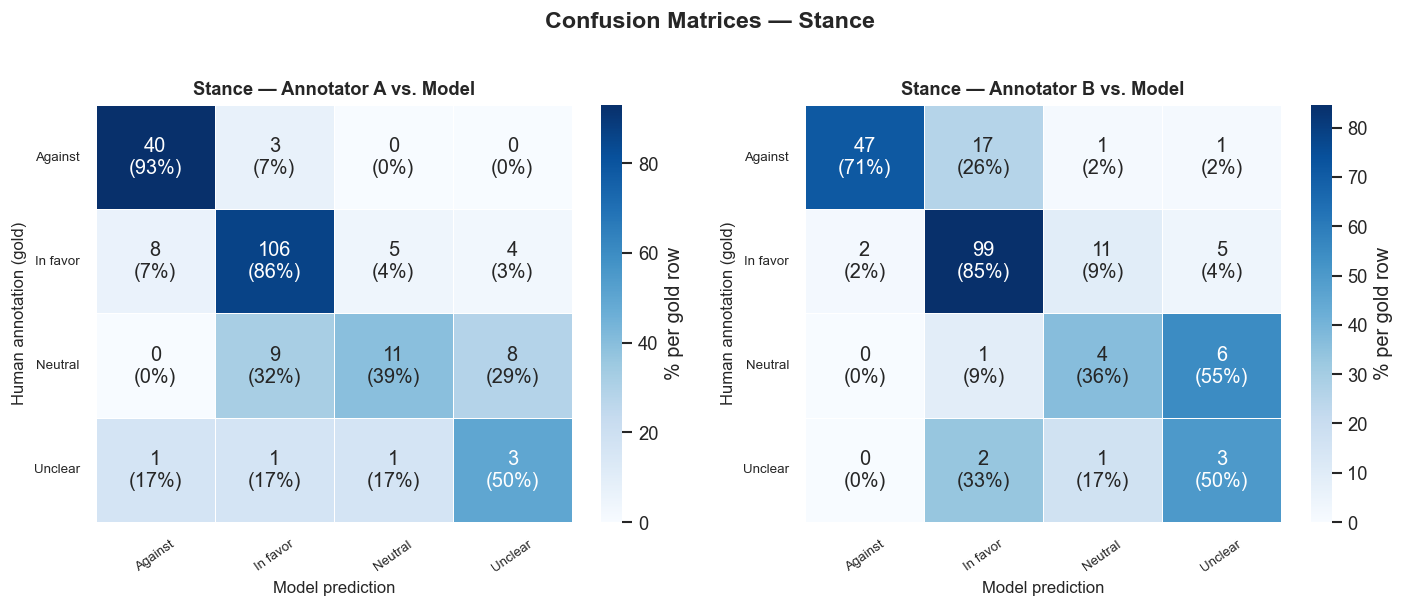

In [148]:
# Stance confusion matrices — one per annotator
fig, axes = plt.subplots(1, len(ANNOTATORS), figsize=(6 * len(ANNOTATORS), 5))
if len(ANNOTATORS) == 1:
    axes = [axes]
for ax, ann in zip(axes, ANNOTATORS):
    df = merged[ann]
    plot_confusion(df['gold_stance'], df['model_stance'], STANCE_LABELS,
                   f'Stance — Annotator {ann} vs. Model', ax)
plt.suptitle('Confusion Matrices — Stance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The stance confusion matrices show that the model performs most reliably on the two dominant polarity categories, `In favor` and `Against`. In particular, `In favor` achieves very stable recall across both annotators, with values of 86% against Annotator A and 85% against Annotator B. Similarly, `Against` reaches very high recall against Annotator A (93%), although its performance decreases noticeably against Annotator B (71%).

This asymmetry in the `Against` category appears to be driven more by annotation differences than by purely model-related errors. Annotator B assigned substantially more tweets to `Against` than Annotator A, suggesting a broader interpretation of negative or critical political discourse. Many of these additional tweets are classified by the model as `In favor`, indicating that when polarity is ambiguous or criticism is indirect, the classifier tends to favour the positive category. This tendency is consistent with the overall polarity bias already observed in the global agreement metrics.

The model shows greater difficulty distinguishing the minority stance categories, particularly `Neutral` and `Unclear`. Recall for `Neutral` remains relatively low, reaching 39% against Annotator A and 36% against Annotator B. However, the confusion patterns differ between annotators. Annotator A used the `Neutral` category more frequently, which likely introduced a larger number of borderline cases that the model interpreted as having an identifiable stance. In contrast, Annotator B applied `Neutral` more conservatively, leading the model to classify many of these tweets as `Unclear` instead.

The `Unclear` category itself contains very few observations, with only six tweets assigned by each annotator. As a result, the corresponding recall values should be interpreted cautiously, since small classification changes strongly affect the percentages. Nevertheless, the confusion matrices reveal an important pattern: although the model does produce `Unclear` predictions, these are often associated with tweets labelled as `Neutral` by the annotators rather than with tweets explicitly marked as `Unclear`. This suggests that the boundary between both categories is inherently unstable and difficult to define consistently, even for human annotators.

This shows that the stance confusion matrices reinforce the conclusions obtained from the global evaluation metrics. The classifier is able to capture explicit positive and negative political positions with substantial agreement, while the main source of disagreement emerges in the distinction between `Neutral` and `Unclear`, where subjective interpretation and contextual ambiguity play a much larger role.

## 6. Per-Class Metrics (Precision / Recall / F1)
This section calculates the per-class performance metrics for the LLM classifications. Unlike the global metrics, which summarize overall agreement, this analysis evaluates each topic and stance category separately.

For each class, three metrics are reported: precision, recall, and F1-score. Precision measures how reliable the model is when it predicts a given category. Recall measures how many human-labelled cases from that category the model is able to recover. F1-score combines both dimensions into a single value. The support column indicates how many examples of each category appear in the gold standard.


Per-Class Metrics — TOPIC (Annotator A vs. Model)
                                    Precision  Recall     F1  Support
Economy and Employment                  0.742   0.852  0.793       27
Immigration and Security                0.615   0.800  0.696       10
International Affairs                   0.926   0.806  0.862       31
National Politics and Governance        0.733   0.821  0.775       67
Other                                   0.833   0.658  0.735       38
Rights and Equality                     0.500   0.714  0.588        7
Welfare, Housing and Social Policy      0.643   0.450  0.529       20

  Macro avg    — P:0.713  R:0.729  F1:0.711
  Weighted avg — P:0.760  R:0.750  F1:0.748


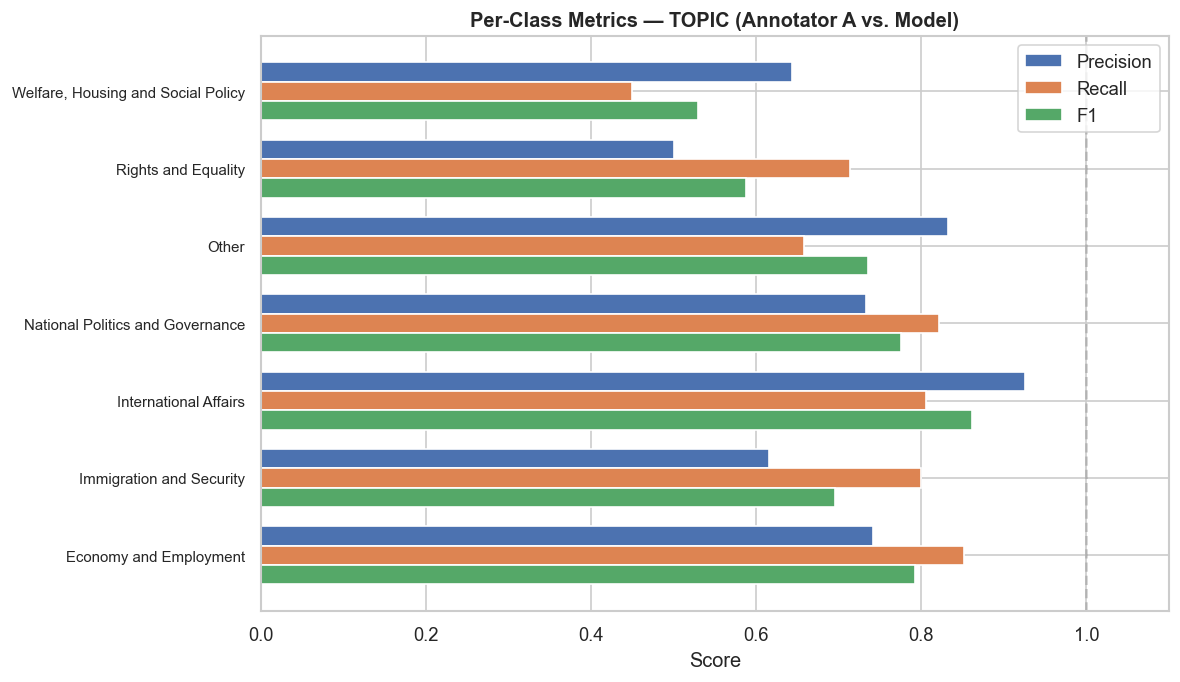


Per-Class Metrics — STANCE (Annotator A vs. Model)
          Precision  Recall     F1  Support
Against       0.816   0.930  0.870       43
In favor      0.891   0.862  0.876      123
Neutral       0.647   0.393  0.489       28
Unclear       0.200   0.500  0.286        6

  Macro avg    — P:0.639  R:0.671  F1:0.630
  Weighted avg — P:0.820  R:0.800  F1:0.803


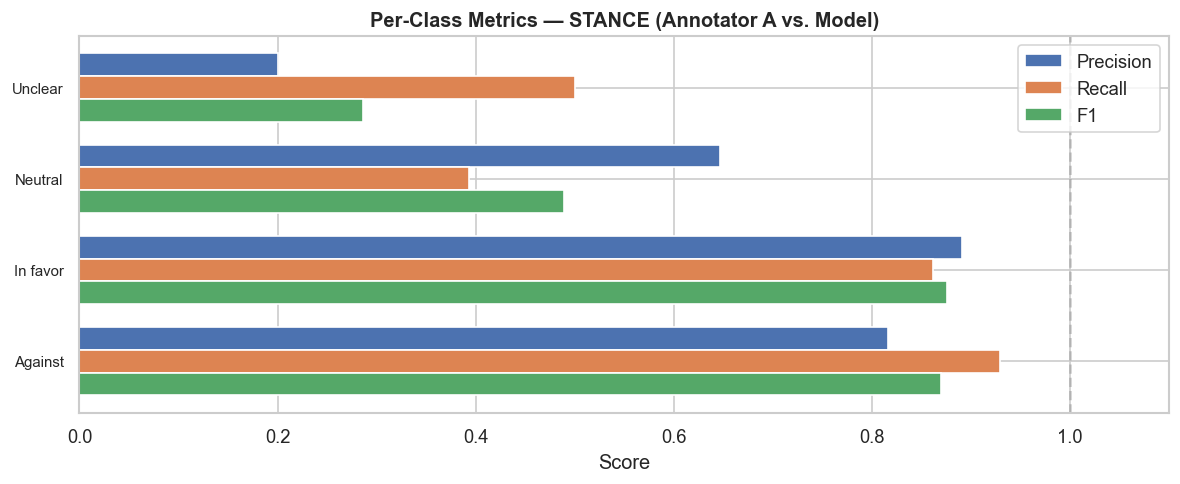


Per-Class Metrics — TOPIC (Annotator B vs. Model)
                                    Precision  Recall     F1  Support
Economy and Employment                  0.581   0.857  0.692       21
Immigration and Security                0.615   0.667  0.640       12
International Affairs                   0.889   0.800  0.842       30
National Politics and Governance        0.680   0.879  0.767       58
Other                                   0.900   0.529  0.667       51
Rights and Equality                     0.400   0.400  0.400       10
Welfare, Housing and Social Policy      0.714   0.556  0.625       18

  Macro avg    — P:0.683  R:0.670  F1:0.662
  Weighted avg — P:0.742  R:0.710  F1:0.706


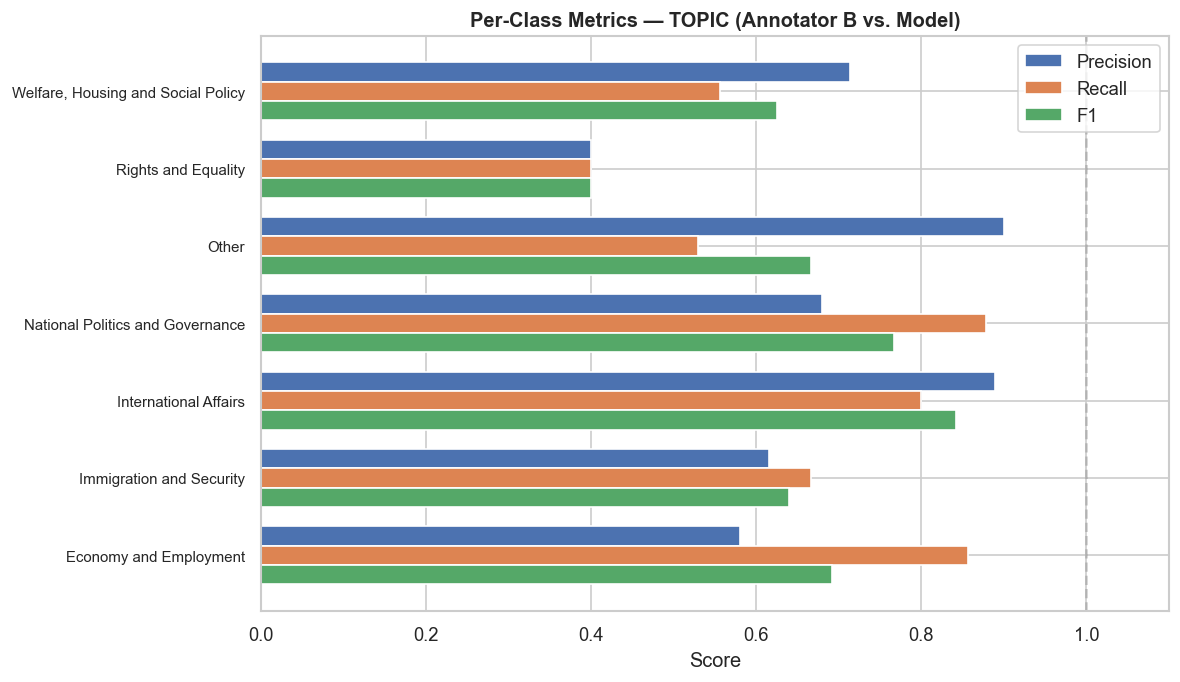


Per-Class Metrics — STANCE (Annotator B vs. Model)
          Precision  Recall     F1  Support
Against       0.959   0.712  0.817       66
In favor      0.832   0.846  0.839      117
Neutral       0.235   0.364  0.286       11
Unclear       0.200   0.500  0.286        6

  Macro avg    — P:0.557  R:0.605  F1:0.557
  Weighted avg — P:0.822  R:0.765  F1:0.785


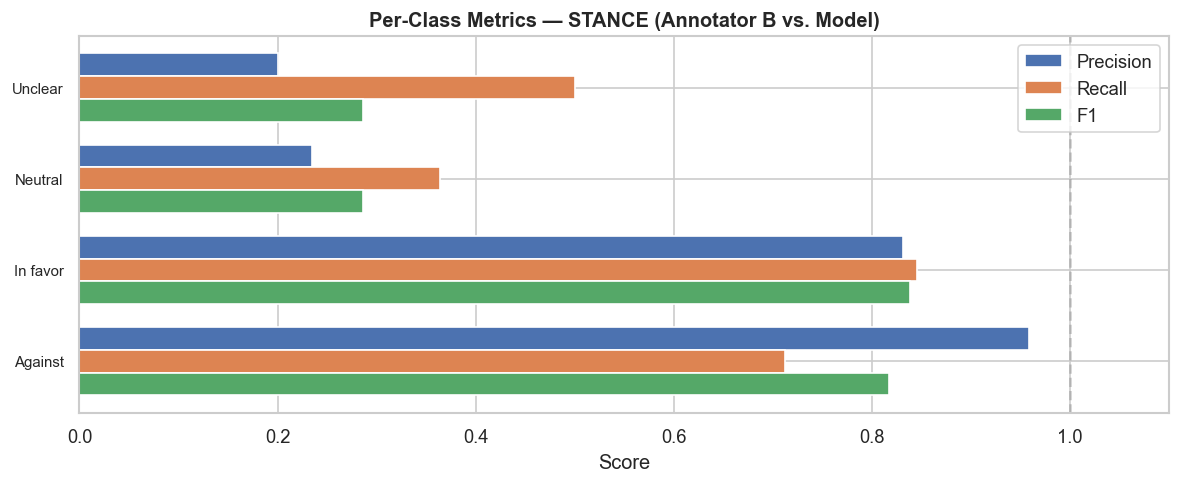

In [149]:
def plot_per_class(y_true, y_pred, labels, title):
    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    df_r = pd.DataFrame({k: report[k] for k in labels}).T[['precision','recall','f1-score','support']]
    df_r.columns = ['Precision', 'Recall', 'F1', 'Support']
    df_r[['Precision','Recall','F1']] = df_r[['Precision','Recall','F1']].round(3)
    df_r['Support'] = df_r['Support'].astype(int)

    macro = report['macro avg']
    weighted = report['weighted avg']
    print(f'\n{title}')
    print(df_r.to_string())
    print(f"\n  Macro avg    — P:{macro['precision']:.3f}  R:{macro['recall']:.3f}  F1:{macro['f1-score']:.3f}")
    print(f"  Weighted avg — P:{weighted['precision']:.3f}  R:{weighted['recall']:.3f}  F1:{weighted['f1-score']:.3f}")

    fig, ax = plt.subplots(figsize=(10, 0.55 * len(labels) + 2))
    x = np.arange(len(labels))
    w = 0.25
    ax.barh(x + w, df_r['Precision'], w, label='Precision', color='#4C72B0')
    ax.barh(x,     df_r['Recall'],    w, label='Recall',    color='#DD8452')
    ax.barh(x - w, df_r['F1'],        w, label='F1',        color='#55A868')
    ax.set_yticks(x)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.axvline(1.0, color='grey', linestyle='--', alpha=0.4)
    ax.legend()
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    plt.tight_layout()
    plt.show()
    return df_r

for ann in ANNOTATORS:
    df = merged[ann]
    plot_per_class(df['gold_topic'],  df['model_topic'],  TOPIC_LABELS,  f'Per-Class Metrics — TOPIC (Annotator {ann} vs. Model)')
    plot_per_class(df['gold_stance'], df['model_stance'], STANCE_LABELS, f'Per-Class Metrics — STANCE (Annotator {ann} vs. Model)')

### Topic per-class metrics

The per-class metrics show that the model performs most consistently on `International Affairs`, `National Politics and Governance`, and `Economy and Employment`. Among these categories, `International Affairs` achieves the strongest overall performance, reaching F1-scores of 0.86 against Annotator A and 0.84 against Annotator B. This result is mainly driven by very high precision values, indicating that when the model predicts this category, it is usually correct. The category likely benefits from the presence of distinctive terms related to countries, political leaders, international conflicts, or diplomatic institutions, which makes the thematic boundaries more explicit.

`National Politics and Governance` also achieves relatively stable performance across both annotators, with F1-scores of 0.77 in both cases. However, the balance between precision and recall differs slightly between annotators. Against Annotator A, the model maintains a more balanced behaviour, while against Annotator B the recall becomes considerably higher than the precision. This suggests that the model tends to assign governance-related labels more aggressively, especially in tweets that contain ambiguous or broadly political content.

`Economy and Employment` obtains strong recall values for both annotators, indicating that the model is generally able to identify tweets related to economic topics. Nevertheless, precision decreases noticeably against Annotator B, which implies that some tweets classified by the model as economic content were interpreted instead as welfare or broader political issues by the annotator. This pattern again reflects the conceptual overlap between several policy-related categories rather than a purely isolated classification error.

The category `Other` presents the opposite behaviour compared to the previous classes. Precision remains relatively high, however, recall is substantially lower, especially against Annotator B. This confirms that the classifier uses the residual category conservatively and tends to reassign ambiguous tweets into broader political categories instead of leaving them unclassified.

The remaining categories constitute the main limitations of the topic classifier. `Welfare, Housing and Social Policy` achieves moderate performance, mainly limited by low recall values, suggesting that many welfare-related tweets are absorbed into neighbouring political or economic categories. `Immigration and Security` shows intermediate and relatively stable results, although without reaching the reliability observed in the dominant categories.

Finally, `Rights and Equality` obtains the weakest performance overall. However, this category also contains the smallest number of examples in the gold standard. Because the support is extremely limited, even one or two different classifications can substantially alter the resulting F1-score. Therefore, these results should be interpreted cautiously and understood as exploratory rather than definitive.

### Stance per-class metrics

The per-class stance metrics reveal a clear contrast between the dominant polarity categories and the minority non-positioned categories. The model performs most consistently on `In favor`, reaching F1-scores of 0.88 against Annotator A and 0.84 against Annotator B. In both cases, precision and recall remain well balanced, indicating that the classifier is able to both identify and recover positive political positions reliably. This stability is also influenced by the high representation of `In favor` tweets within the dataset.

`Against` is the category that provides the most insight into the interaction between model behaviour and annotation variability. Against Annotator A, the model achieves very strong performance, with high recall and good precision, resulting in an F1-score of 0.87. Against Annotator B, the F1-score remains relatively high at 0.82, although the balance between precision and recall changes substantially. Precision becomes extremely high, while recall decreases noticeably. This suggests that the model applies the `Against` label more conservatively than Annotator B. In practice, many tweets that B considered negative or critical were instead interpreted by the model as either `In favor` or non-positioned content. Therefore, the lower recall against Annotator B appears to reflect differences in annotation criteria rather than a simple classification failure.

The model shows considerably weaker performance on the minority stance categories, especially `Neutral` and `Unclear`. `Neutral` achieves relatively low F1-scores, particularly against Annotator B. Against Annotator A, the main limitation comes from recall, meaning that the classifier frequently fails to identify tweets labelled as neutral and instead assigns them to neighbouring stance categories. Against Annotator B, both precision and recall decrease, suggesting that the tweets included in B’s `Neutral` category differ substantially from the patterns learned by the model.

The category `Unclear` presents the lowest and most unstable results. Precision remains very low, indicating that many tweets predicted as `Unclear` were interpreted differently by the annotators. At the same time, recall values show that the model still misses approximately half of the tweets manually labelled as unclear. Since this category contains very few observations in the gold standard, the resulting metrics are highly sensitive to even minor classification changes. Nevertheless, the consistent confusion pattern across both annotators suggests that the distinction between `Neutral` and `Unclear` is intrinsically difficult, even for humans.

From this, it is shown that the stance results indicate that the model is effective at detecting explicit political positioning, particularly positive and negative polarity, while the main source of disagreement emerges in the interpretation of non-positioned tweets. This supports the idea that the boundary between `Neutral` and `Unclear` is conceptually unstable and strongly dependent on subjective interpretation and contextual ambiguity.

## 7. Disagreement Analysis
This section performs a detailed error analysis of the model predictions by comparing the gold-standard annotations with the LLM classifications at the tweet level. In addition to measuring overall agreement, the objective is to identify the most frequent error patterns and determine whether disagreements occur mainly in topic classification, stance classification, or both simultaneously.

To facilitate this analysis, three Boolean variables are created for each tweet: one indicating whether the topic prediction is correct, another for stance correctness, and a third combining both conditions.

In [150]:
for ann in ANNOTATORS:
    df = merged[ann].copy()
    df['topic_ok']  = df['gold_topic']  == df['model_topic']
    df['stance_ok'] = df['gold_stance'] == df['model_stance']
    df['both_ok']   = df['topic_ok'] & df['stance_ok']
    merged[ann] = df  # store flags for export

    print(f'── Annotator {ann} ──────────────────────────────')
    print(f"  Both correct              : {df['both_ok'].sum()} ({df['both_ok'].mean()*100:.1f}%)")
    print(f"  Only topic correct        : {(df['topic_ok'] & ~df['stance_ok']).sum()}")
    print(f"  Only stance correct       : {(~df['topic_ok'] & df['stance_ok']).sum()}")
    print(f"  Neither correct           : {(~df['topic_ok'] & ~df['stance_ok']).sum()}")

    topic_err = df[~df['topic_ok']].copy()
    topic_err['pair'] = topic_err['gold_topic'] + ' → ' + topic_err['model_topic']
    print(f'\n  Top topic errors (gold → model):')
    for pair, cnt in topic_err['pair'].value_counts().head(5).items():
        print(f'    {cnt:3d}  {pair}')

    stance_err = df[~df['stance_ok']].copy()
    stance_err['pair'] = stance_err['gold_stance'] + ' → ' + stance_err['model_stance']
    print(f'\n  Stance errors (gold → model):')
    for pair, cnt in stance_err['pair'].value_counts().items():
        print(f'    {cnt:3d}  {pair}')
    print()

── Annotator A ──────────────────────────────
  Both correct              : 125 (62.5%)
  Only topic correct        : 25
  Only stance correct       : 35
  Neither correct           : 15

  Top topic errors (gold → model):
     12  Other → National Politics and Governance
      5  Welfare, Housing and Social Policy → National Politics and Governance
      3  National Politics and Governance → Economy and Employment
      3  Welfare, Housing and Social Policy → Economy and Employment
      2  International Affairs → National Politics and Governance

  Stance errors (gold → model):
      9  Neutral → In favor
      8  Neutral → Unclear
      8  In favor → Against
      5  In favor → Neutral
      4  In favor → Unclear
      3  Against → In favor
      1  Unclear → In favor
      1  Unclear → Against
      1  Unclear → Neutral

── Annotator B ──────────────────────────────
  Both correct              : 111 (55.5%)
  Only topic correct        : 31
  Only stance correct       : 42
  Neither

### Joint accuracy and dominant error pairs

The joint accuracy analysis represents the strictest evaluation criterion in the study, since a tweet is considered correctly classified only when both the topic and the stance predictions match the gold-standard annotation simultaneously. Under this condition, the model correctly classifies 62.5% of tweets against Annotator A and 55.5% against Annotator B. These values are lower than the independent topic and stance accuracies reported previously, indicating that classification errors usually affect only one dimension at a time rather than both simultaneously.

The distribution of partial matches reinforces this interpretation. In both annotator comparisons, the model achieves “only stance correct” cases more frequently than “only topic correct” cases. This suggests that stance classification is generally easier for the model than topic classification. One possible explanation is that the stance task contains fewer categories, making agreement statistically easier to achieve. Additionally, the dominant `In favor` category occupies a large proportion of the dataset, increasing the probability of correct stance predictions.

The proportion of tweets where neither topic nor stance are correctly classified remains relatively small in both samples. These tweets are particularly relevant for qualitative analysis, since they likely correspond to the most ambiguous or context-dependent messages in the corpus.

#### Topic error structure

The topic error analysis confirms the main confusion patterns already observed in the confusion matrices. The most frequent error in both annotator comparisons is the reassignment of `Other` tweets to `National Politics and Governance`. This pattern indicates that the classifier tends to interpret ambiguous political content as governance-related instead of assigning it to the residual category.

Part of this disagreement may be explained by differences in the contextual information between the annotators and the classifier mentioned earlier. 

Another frequent source of disagreement involves `Welfare, Housing and Social Policy` being reassigned to `National Politics and Governance`. This reflects the strong thematic overlap between welfare debates and broader institutional political discussions. Similarly, some governance-related tweets are classified by the model as `Economy and Employment`, suggesting that the classifier sometimes prioritizes the economic framing of political content.

Differences between annotators also appear in the interpretation of immigration-related tweets. In particular, Annotator B shows a higher number of `Immigration and Security → Rights and Equality` disagreements, indicating a more rights-oriented interpretation of migration issues compared to Annotator A.

#### Stance error structure

The stance error analysis highlights a consistent tendency of the model to favour the positive polarity category. The clearest example appears in the `Against → In favor` transition, especially against Annotator B. This suggests that tweets interpreted by B as critical or negative are frequently classified by the model as supportive or positively framed content.

The analysis also reinforces the instability of the boundary between positioned and non-positioned tweets. For Annotator A, many tweets labelled as `Neutral` are reassigned either to `In favor` or `Unclear`, indicating that the classifier often interprets weakly expressed positions as containing some degree of polarity.

Against Annotator B, the confusion pattern changes slightly, although disagreements involving `Neutral` and `Unclear` remain one of the dominant sources of error. This suggests that the distinction between these categories depends heavily on subjective interpretation and annotation criteria.

In [151]:
# Concrete disagreement examples
cols_show = ['tweet', 'gold_topic', 'model_topic', 'gold_stance', 'model_stance']

for ann in ANNOTATORS:
    df = merged[ann]
    print(f'══ Annotator {ann} — Topic disagreement examples ══')
    sample = df[~df['topic_ok']][cols_show].sample(min(5, (~df['topic_ok']).sum()), random_state=42)
    for _, row in sample.iterrows():
        text = row['tweet'][:120] + '...' if len(str(row['tweet'])) > 120 else row['tweet']
        print(f"  Tweet       : {text}")
        print(f"  Gold topic  : {row['gold_topic']}")
        print(f"  Model topic : {row['model_topic']}")
        print()

    print(f'══ Annotator {ann} — Stance disagreement examples ══')
    sample = df[~df['stance_ok']][cols_show].sample(min(5, (~df['stance_ok']).sum()), random_state=42)
    for _, row in sample.iterrows():
        text = row['tweet'][:120] + '...' if len(str(row['tweet'])) > 120 else row['tweet']
        print(f"  Tweet        : {text}")
        print(f"  Gold stance  : {row['gold_stance']}")
        print(f"  Model stance : {row['model_stance']}")
        print()

══ Annotator A — Topic disagreement examples ══
  Tweet       : GRACIAS JAÉN#CambioReal@vox_es @Macarena_Olona
  Gold topic  : Other
  Model topic : National Politics and Governance

  Tweet       : Aquest dissabte, serem a la Fira de Sabadell (17h) per continuar amb el procés d'escolta a Catalunya Avui he tingut l'op...
  Gold topic  : Other
  Model topic : National Politics and Governance

  Tweet       : Han controlado las redes sociales durante 7 años. Han censurado y envenenado a las sociedades occidentales, liquidando l...
  Gold topic  : Welfare, Housing and Social Policy
  Model topic : National Politics and Governance

  Tweet       : La consecuencia última de todas las políticas de Sánchez y sus socios es arruinar, precarizar, humillar y despreciar a l...
  Gold topic  : National Politics and Governance
  Model topic : Economy and Employment

  Tweet       : No va de cartas. A la derecha se le para con hechos.Gobernando más y mejor. Subiendo salarios, bajando alquileres, crea

## 8. Inter-Annotator Agreement (A vs B)

This section evaluates the inter-annotator agreement (IAA) between Annotator A and Annotator B. The objective is to measure the consistency of the manual annotation process independently of the model predictions.

Only tweets annotated by both annotators are included in the analysis. After aligning the common tweets, agreement is calculated separately for topic classification and stance classification using accuracy and Cohen’s Kappa.

In [152]:
if len(common_tweets) == 0:
    print('No tweets in common between Annotator A and B — skipping IAA.')
else:
    gold_A = gold['A'][gold['A']['tweet_norm'].isin(common_tweets)].set_index('tweet_norm')
    gold_B = gold['B'][gold['B']['tweet_norm'].isin(common_tweets)].set_index('tweet_norm')

    # Align on common index
    common_idx = gold_A.index.intersection(gold_B.index)
    A_topic  = gold_A.loc[common_idx, 'annotator_topic']
    B_topic  = gold_B.loc[common_idx, 'annotator_topic']
    A_stance = gold_A.loc[common_idx, 'annotator_stance']
    B_stance = gold_B.loc[common_idx, 'annotator_stance']

    print(f'Tweets used for IAA: {len(common_idx)}')
    print()
    print_agreement(A_topic,  B_topic,  'TOPIC  (A vs B)')
    print()
    print_agreement(A_stance, B_stance, 'STANCE (A vs B)')


kappa_AB_topic  = cohen_kappa_score(A_topic.astype(str),  B_topic.astype(str),  labels=TOPIC_LABELS)
kappa_AB_stance = cohen_kappa_score(A_stance.astype(str), B_stance.astype(str), labels=STANCE_LABELS)

Tweets used for IAA: 200

  [TOPIC  (A vs B)]
    Tweets evaluated : 200
    Agreements       : 140 (70.0%)
    Disagreements    : 60 (30.0%)
    Accuracy         : 0.7000
    Cohen's Kappa    : 0.6265  (substantial)
    95% CI for Kappa : [0.5501, 0.7024]

  [STANCE (A vs B)]
    Tweets evaluated : 200
    Agreements       : 152 (76.0%)
    Disagreements    : 48 (24.0%)
    Accuracy         : 0.7600
    Cohen's Kappa    : 0.5719  (moderate)
    95% CI for Kappa : [0.4716, 0.6639]


The inter-annotator agreement results indicate that the manual annotation process achieved reasonably consistent levels of agreement across both tasks, although important sources of ambiguity remain present.

For topic classification, the annotators agreed on 140 out of 200 tweets, corresponding to an accuracy of 70.0%. Cohen’s Kappa reaches 0.63, which falls within the range commonly interpreted as substantial agreement. This suggests that the topic coding scheme is generally stable and reproducible, despite the conceptual overlap that exists between some categories such as `National Politics and Governance`, `Economy and Employment`, and `Welfare, Housing and Social Policy`.

The disagreement rate of 30% also indicates that topic classification in political tweets remains inherently subjective in a significant number of cases. Many tweets contain multiple thematic dimensions simultaneously, making the assignment of a single dominant topic difficult even for human annotators.

For stance classification, the annotators achieved a higher raw agreement of 76.0%, corresponding to 152 matching annotations out of 200 tweets. However, Cohen’s Kappa decreases to 0.57, which corresponds to moderate agreement. This apparent contradiction reflects the effect of class imbalance, particularly the high prevalence of the `In favor` category. Since a large proportion of tweets belong to the dominant stance class, part of the observed agreement occurs by chance, which reduces the Kappa score after correction.

The stance results also confirm that the distinction between `Neutral` and `Unclear` is especially unstable. Unlike explicit positive or negative positioning, non-positioned tweets often depend heavily on subjective interpretation, contextual assumptions, or implicit political framing. Consequently, even human annotators do not consistently separate these categories in the same way.

The inter-annotator agreement values indicate that the annotation process is sufficiently reliable to serve as a gold standard for evaluation purposes, while also highlighting the intrinsic ambiguity of political discourse classification on social media. Importantly, these agreement levels provide a realistic upper bound for model performance, since part of the disagreement originates from human interpretation itself rather than from model limitations alone.

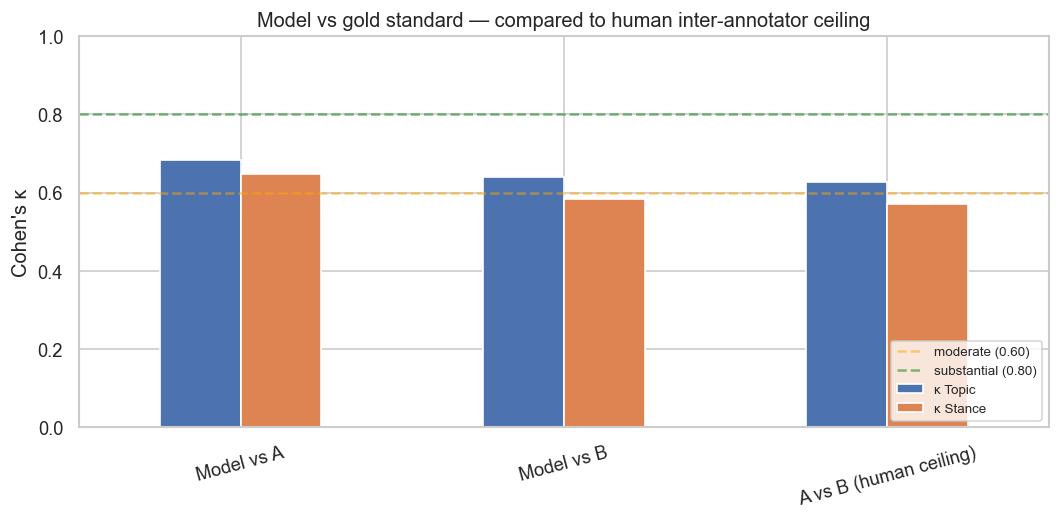

,κ Topic,κ Stance
Model vs A,0.684,0.647
Model vs B,0.639,0.583
A vs B (human ceiling),0.627,0.572


In [154]:
# Comparativa: techo humano vs modelo
comparison = pd.DataFrame({
    'κ Topic':  [results['A']['kappa_topic'],
                 results['B']['kappa_topic'],
                 kappa_AB_topic],
    'κ Stance': [results['A']['kappa_stance'],
                 results['B']['kappa_stance'],
                 kappa_AB_stance],
}, index=['Model vs A', 'Model vs B', 'A vs B (human ceiling)'])

ax = comparison.plot.bar(rot=15, figsize=(9,4.5),
                         color=['#4C72B0','#DD8452'], edgecolor='white')
ax.axhline(0.60, ls='--', color='orange', alpha=0.5, label='moderate (0.60)')
ax.axhline(0.80, ls='--', color='green',  alpha=0.5, label='substantial (0.80)')
ax.set_ylim(0,1); ax.set_ylabel("Cohen's κ")
ax.set_title("Model vs gold standard — compared to human inter-annotator ceiling")
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()
display(comparison.round(3))

This figure compares the agreement obtained by the model against each annotator with the agreement achieved between the annotators themselves. The third group of bars (`A vs B`) represents the human inter-annotator ceiling, which can be interpreted as an approximate upper bound for achievable agreement in this task. Since the annotation process itself contains ambiguity and subjective interpretation, even a theoretically perfect classifier would not necessarily achieve complete agreement with every annotator.

The comparison reveals one of the most important findings of the evaluation. In both topic and stance classification, the model reaches agreement levels comparable to, and in some cases slightly higher than, the agreement observed between the two annotators.

For topic classification, the model achieves a Cohen’s Kappa of 0.684 against Annotator A and 0.639 against Annotator B, while the agreement between annotators reaches 0.627. Similarly, for stance classification, the model obtains Kappa values of 0.647 and 0.583, compared to a human inter-annotator agreement of 0.572.

These results suggest that the moderate-to-substantial agreement values reported throughout the evaluation are not simply a consequence of model limitations, but also reflect the intrinsic difficulty of the annotation task itself. In practice, the classifier reproduces the annotation behaviour of individual annotators at approximately the same level that the annotators agree with one another.

Nevertheless, several methodological caveats should be considered when interpreting these results. First, the inter-annotator agreement estimates are calculated from a relatively small shared sample of 200 tweets, meaning that small Kappa differences should not be interpreted as evidence that the model genuinely “outperforms” human annotators. Second, the model had access to metadata such as politician identity and temporal context, while annotators were instructed to classify tweets based only on the isolated text. Consequently, part of the model’s apparent advantage may derive from this contextual asymmetry rather than from superior classification ability.

Finally, agreement should not be confused with objective correctness. A higher agreement score against a given annotator does not imply that the model captures the “true” interpretation of a tweet, but rather that its predictions align with human annotation patterns at a comparable frequency.

With these caveats in mind, the main conclusion remains robust: the LLM-based classifier achieves agreement levels that approach the practical ceiling imposed by human annotation consistency. For a subjective and context-dependent task such as political discourse classification on social media, this represents a strong evaluation result.

In [155]:
print('── Stance binarized: In favor vs Against (sin Neutral/Unclear) ──')
for ann in ANNOTATORS:
    df = merged[ann]
    mask = df['gold_stance'].isin(['In favor','Against']) & df['model_stance'].isin(['In favor','Against'])
    print(f'\nAnnotator {ann}  (n={mask.sum()})')
    print_agreement(df.loc[mask,'gold_stance'],
                    df.loc[mask,'model_stance'],
                    'STANCE binarized', labels=['In favor','Against'])

── Stance binarized: In favor vs Against (sin Neutral/Unclear) ──

Annotator A  (n=157)
  [STANCE binarized]
    Tweets evaluated : 157
    Agreements       : 146 (93.0%)
    Disagreements    : 11 (7.0%)
    Accuracy         : 0.9299
    Cohen's Kappa    : 0.8300  (almost perfect)
    95% CI for Kappa : [0.7317, 0.9146]

Annotator B  (n=165)
  [STANCE binarized]
    Tweets evaluated : 165
    Agreements       : 146 (88.5%)
    Disagreements    : 19 (11.5%)
    Accuracy         : 0.8848
    Cohen's Kappa    : 0.7466  (substantial)
    95% CI for Kappa : [0.6383, 0.8560]


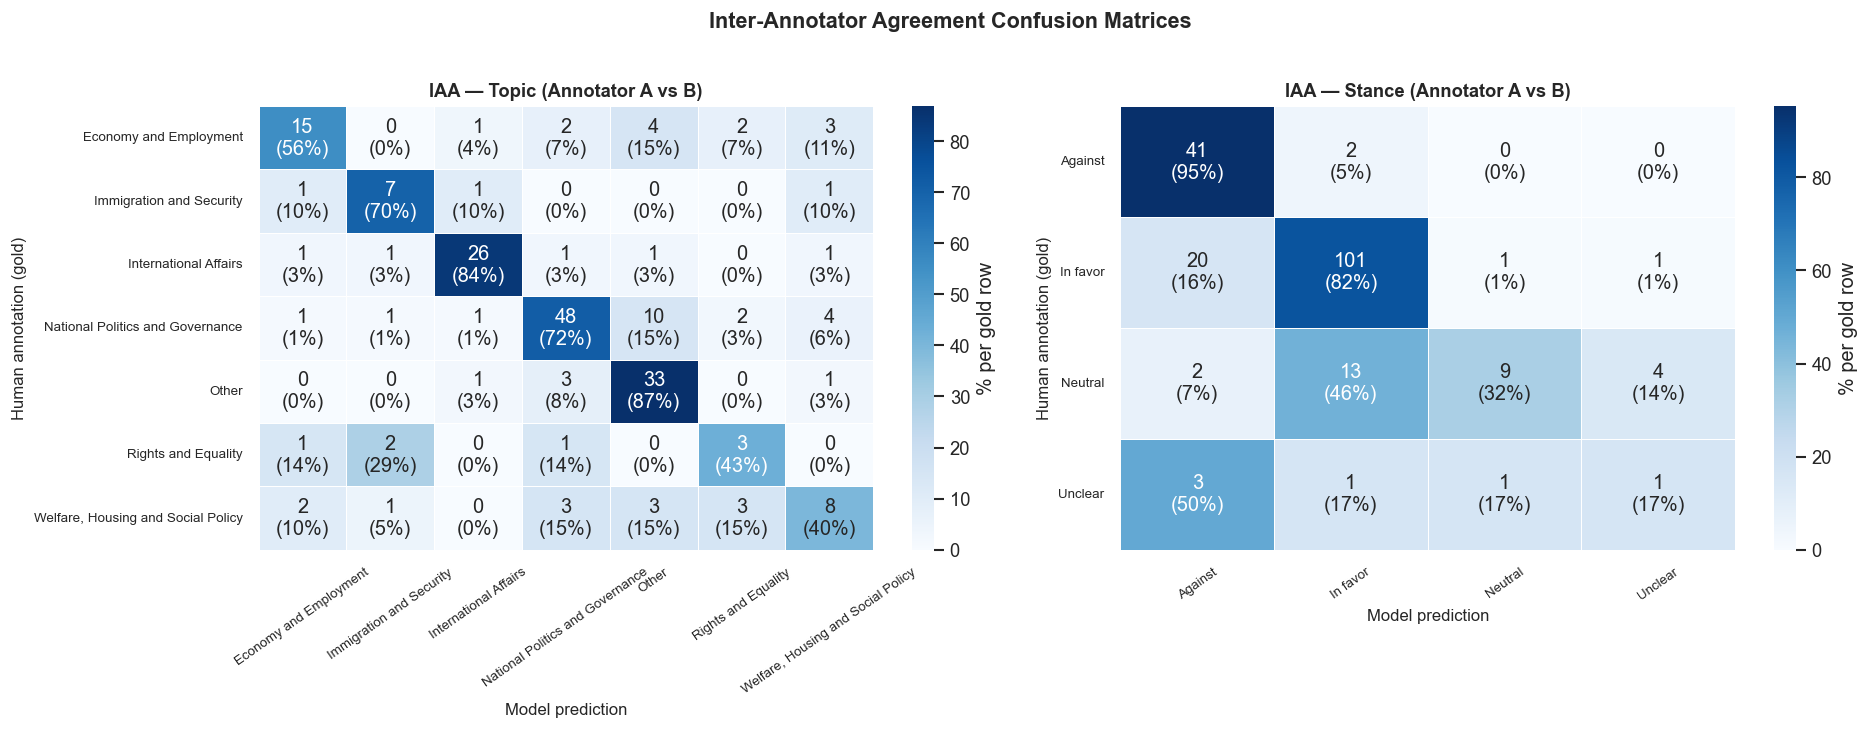

In [156]:
if len(common_tweets) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plot_confusion(A_topic,  B_topic,  TOPIC_LABELS,  'IAA — Topic (Annotator A vs B)',  axes[0])
    plot_confusion(A_stance, B_stance, STANCE_LABELS, 'IAA — Stance (Annotator A vs B)', axes[1])
    plt.suptitle('Inter-Annotator Agreement Confusion Matrices', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

The inter-annotator confusion matrices provide a more detailed view of the disagreements between Annotator A and Annotator B by showing which categories are most frequently confused during the manual annotation process.

For topic classification, the strongest agreement appears in `Other`, `International Affairs`, and `National Politics and Governance`, all of which concentrate a large proportion of observations along the diagonal of the matrix. `International Affairs` reaches particularly high consistency between annotators, suggesting that this category contains clearer thematic boundaries and more distinctive vocabulary than the rest of the coding scheme.

In contrast, the largest disagreements emerge in categories with strong conceptual overlap. `Welfare, Housing and Social Policy` is frequently confused with `National Politics and Governance` and `Other`, indicating that social policy discussions are often interpreted either as broad political discourse or as insufficiently thematic content. Similarly, some disagreements appear between `Economy and Employment` and `Other`, reinforcing the idea that the residual category is interpreted differently by each annotator.

The confusion matrix also highlights that `Rights and Equality` suffers from relatively low agreement. However, this category contains very few observations, meaning that even a small number of disagreements can substantially affect the percentages. The instability observed in minority categories therefore reflects both thematic ambiguity and limited sample size.

The stance confusion matrix reveals a different structure. Agreement is extremely high for explicit negative positioning, with `Against` reaching 95% agreement between annotators. `In favor` also shows strong consistency, achieving 82% agreement. These results indicate that explicit political polarity is generally easy to identify manually.

Most disagreements are concentrated in the `Neutral` and `Unclear` categories. In particular, a large proportion of tweets labelled as `Neutral` by one annotator are classified as `In favor` by the other. This suggests that weakly expressed or implicit political positioning is interpreted differently depending on the annotator’s criteria and sensitivity to contextual cues.

The `Unclear` category shows the greatest instability overall. Half of the tweets labelled as `Unclear` by one annotator are classified as `Against` by the other, while the remaining cases are distributed across the other stance categories. This confirms that the distinction between genuinely unclassifiable tweets and weakly positioned tweets is highly subjective.

The inter-annotator confusion matrices reinforce one of the central conclusions of the evaluation: disagreement does not arise uniformly across all categories, but is concentrated in conceptually overlapping and context-dependent cases. This explains why the classifier can achieve agreement levels close to the human ceiling while still producing substantial disagreements in ambiguous categories.

## 9. Export Results

In [157]:
output_cols = [
    'tweet_id', 'politician', 'date', 'tweet',
    'gold_topic', 'model_topic', 'topic_ok',
    'gold_stance', 'model_stance', 'stance_ok', 'both_ok'
]

with pd.ExcelWriter('gold_standard_comparison_results.xlsx', engine='openpyxl') as writer:
    for ann in ANNOTATORS:
        merged[ann][output_cols].to_excel(writer, sheet_name=f'Annotator_{ann}', index=False)
    
    # Summary sheet
    summary_rows = []
    for ann in ANNOTATORS:
        r = results[ann]
        summary_rows.append({
            'Annotator': ann,
            'N tweets': len(merged[ann]),
            'Topic Accuracy':  round(r['acc_topic'],   4),
            'Topic Kappa':     round(r['kappa_topic'], 4),
            'Topic Kappa CI':  f"[{r['ci_topic'][0]:.3f}, {r['ci_topic'][1]:.3f}]",
            'Topic Macro-F1':  round(r['f1_macro_topic'], 4),
            'Stance Accuracy': round(r['acc_stance'],  4),
            'Stance Kappa':    round(r['kappa_stance'],4),
            'Stance Kappa CI': f"[{r['ci_stance'][0]:.3f}, {r['ci_stance'][1]:.3f}]",
            'Stance Macro-F1': round(r['f1_macro_stance'], 4),
            'Annotator': 'A vs B (IAA)',
            'N tweets': len(common_idx),
            'Topic Kappa':     round(kappa_AB_topic, 4),
            'Stance Kappa':    round(kappa_AB_stance, 4),
        })
    pd.DataFrame(summary_rows).to_excel(writer, sheet_name='Summary', index=False)


print('Exported: gold_standard_comparison_results.xlsx')
print('  Sheets: Annotator_A, Annotator_B, Summary')

Exported: gold_standard_comparison_results.xlsx
  Sheets: Annotator_A, Annotator_B, Summary
